# Orders data analysis using matplotlib

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv


In [7]:
# Load database credentials and create engine

load_dotenv()

db_name = os.getenv('DB_NAME')
db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')

engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")

## Create dataframe from CSV file


In [8]:
# Read orders table from the database
query = 'SELECT * FROM orders'
df_orders = pd.read_sql_query(query, engine)

print("Orders:")
display(df_orders.head())

Orders:


,order_id,customer_id,product_id,order_date,quantity,unit_price,total_amount,order_status,payment_method
0,ORD-000001,CUST-0251,PRD_328,2023-02-21,1,27.96,27.96,Completed,Credit Card
1,ORD-000002,CUST-0033,PRD_347,2023-06-28,5,51.74,258.70,Completed,Debit Card
2,ORD-000003,CUST-0734,PRD_120,2023-02-24,5,96.94,484.70,Completed,Google Pay
3,ORD-000004,CUST-0829,PRD_215,2025-07-08,2,35.22,70.44,Pending,Debit Card
4,ORD-000005,CUST-0221,PRD_358,2024-11-27,4,10.92,43.68,Returned,PayPal


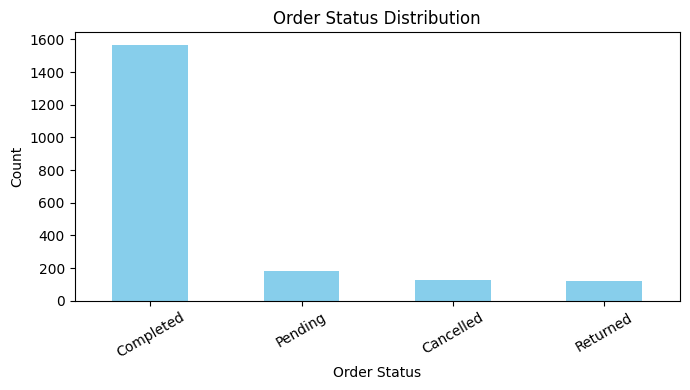

In [9]:
# 1. Order Status Distribution
order_status_counts = df_orders['order_status'].value_counts()
plt.figure(figsize=(7,4))
order_status_counts.plot(kind='bar', color='skyblue')
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

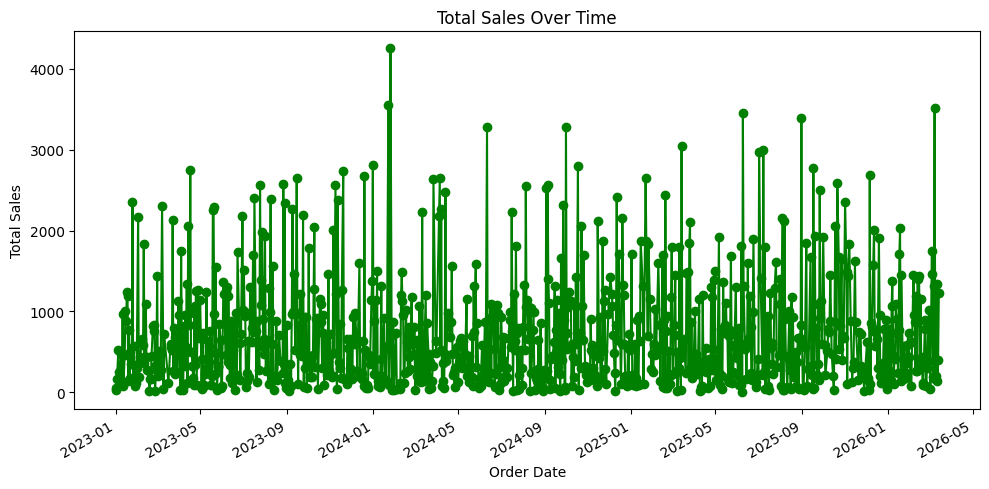

In [10]:
# 2. Total Sales Over Time
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
sales_by_date = df_orders.groupby('order_date')['total_amount'].sum()
plt.figure(figsize=(10,5))
sales_by_date.plot(kind='line', marker='o', color='green')
plt.title('Total Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

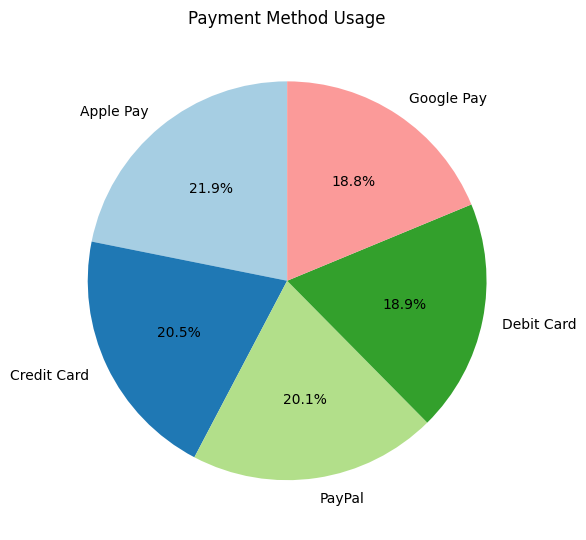

In [11]:
# 3. Payment Method Usage
payment_counts = df_orders['payment_method'].value_counts()
plt.figure(figsize=(6,6))
payment_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Payment Method Usage')
plt.ylabel('')
plt.tight_layout()
plt.show()